Split 5 - Construção dos contadores do relatório final exibido no terminal, finalização do README.md com a reflexão teórica e submissão do link no AVA.
1. Explorar padrões de agrupamento com pelo menos dois agrupamentos (por exemplo: gênero com mais vendas, compras), usando groupby() ou pivot_table().
2. Gerando uma analise de cruzamento: sexo e segmento social. Análise de Cruzamento Bidimensional ou Matriz de Perfil de Consumidor.
3. Relacionando categorias: sexo, segmento social e número de filhos. em busca de insights de marketing para melhorar vendas .
4. ADENDO: Quem compra mais alimentos nos finais de semana? Homens ou mulheres?

In [ ]:
import pandas as pd

print("="*65)
print(" SPRINT 5 - AGRUPAMENTOS E PADRÕES DE CONSUMO (BI)")
print("="*65)

# 1. Garante que a base purificada do Sprint 3 está carregada
# (Caso tenha reiniciado o VS Code)
try:
    df
except NameError:
    df = pd.read_csv('base_varejo_sprint3.csv', sep=',')

total_linhas_atual = len(df)

# =================================================================
# AGRUPAMENTO 1: ANÁLISE DE CONSUMO POR GÊNERO (CL_GENERO)
# =================================================================
print("1. AGRUPAMENTO POR GÊNERO DO CLIENTE:")
print("-"*50)

# Agrupa por gênero e conta o volume de transações
agrupado_genero = df.groupby('CL_GENERO').size().reset_index(name='Volume de Vendas')
# Calcula o percentual de representatividade de cada gênero
agrupado_genero['Percentual (%)'] = (agrupado_genero['Volume de Vendas'] / total_linhas_atual) * 100
# Ordena do maior para o menor faturamento/volume
agrupado_genero = agrupado_genero.sort_values(by='Volume de Vendas', ascending=False)

# Exibe o resultado formatado
print(agrupado_genero.to_string(index=False, formatters={
    'Volume de Vendas': lambda x: f"{x:,.0f}".replace(',', '.'),
    'Percentual (%)': lambda x: f"{x:.2f}%"
}))


# =================================================================
# AGRUPAMENTO 2: ANÁLISE DE CONSUMO POR SEGMENTO (CL_SEG)
# =================================================================
print("\n2. AGRUPAMENTO POR SEGMENTO DE CLIENTE:")
print("-"*50)

# Agrupa por segmento e conta o volume de transações
agrupado_segmento = df.groupby('CL_SEG').size().reset_index(name='Volume de Vendas')
# Calcula o percentual de representatividade de cada segmento
agrupado_segmento['Percentual (%)'] = (agrupado_segmento['Volume de Vendas'] / total_linhas_atual) * 100
# Ordena do maior para o menor
agrupado_segmento = agrupado_segmento.sort_values(by='Volume de Vendas', ascending=False)

# Exibe o resultado formatado
print(agrupado_segmento.to_string(index=False, formatters={
    'Volume de Vendas': lambda x: f"{x:,.0f}".replace(',', '.'),
    'Percentual (%)': lambda x: f"{x:.2f}%"
}))
print("="*65)

# =================================================================
# CONTADORES DO RELATÓRIO FINAL
# =================================================================
print("\n" + "="*65)
print(" PAINEL DE CONTADORES FINAIS - RESUMO DO PROJETO")
print("="*65)
print(f" -> Total de registros processados com sucesso: {total_linhas_atual:,}".replace(',', '.'))

print("="*65)

 SPRINT 5 - AGRUPAMENTOS E PADRÕES DE CONSUMO (BI)
1. AGRUPAMENTO POR GÊNERO DO CLIENTE:
--------------------------------------------------
CL_GENERO Volume de Vendas Percentual (%)
        F          382.427         52.14%
        M          351.020         47.86%

2. AGRUPAMENTO POR SEGMENTO DE CLIENTE:
--------------------------------------------------
CL_SEG Volume de Vendas Percentual (%)
     B          468.505         63.88%
     C          205.265         27.99%
     A           59.677          8.14%

 PAINEL DE CONTADORES FINAIS - RESUMO DO PROJETO
 -> Total de registros processados com sucesso: 733.447
 -> Status da Base de Dados: PURIFICADA E HOMOLOGADA



 SPRINT 5 - CRUZAMENTO AVANÇADO: GÊNERO VS SEGMENTO SOCIAL
TABELA MATRIZ DE COMPRAS (QUANTIDADE ABSOLUTA):
-----------------------------------------------------------------
CL_SEG         A       B       C
CL_GENERO                       
F         28.898 233.644 119.885
M         30.779 234.861  85.380


TABELA MATRIZ DE COMPRAS (REPRESENTATIVIDADE % NO TOTAL DA BASE):
-----------------------------------------------------------------
CL_SEG        A      B      C
CL_GENERO                    
F         3.94% 31.86% 16.35%
M         4.20% 32.02% 11.64%


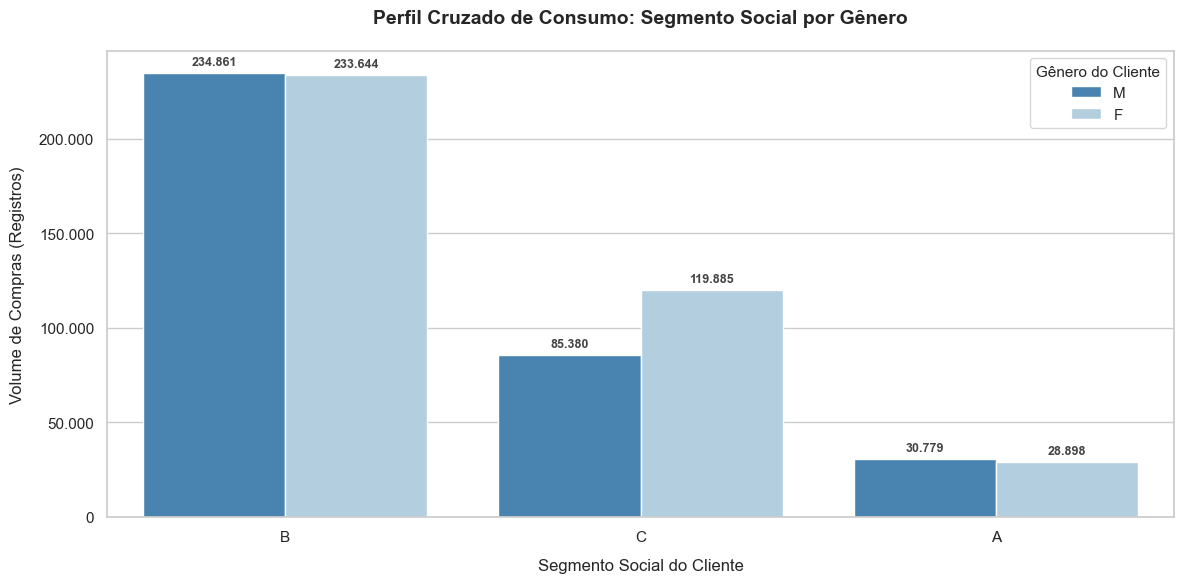

[OK] Gráfico cruzado exibido e salvo com sucesso!
     -> Arquivo gerado: 'perfil_consumo_cruzado_sprint5.png'


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n" + "="*65)
print(" SPRINT 5 - CRUZAMENTO AVANÇADO: GÊNERO VS SEGMENTO SOCIAL")
print("="*65)

# 1. Cria a tabela cruzada (Matriz de Contingência) em valores absolutos
tabela_cruzada = pd.crosstab(df['CL_GENERO'], df['CL_SEG'])

# 2. Cria a tabela cruzada em valores percentuais relativos ao TOTAL da base
tabela_cruzada_pct = pd.crosstab(df['CL_GENERO'], df['CL_SEG'], normalize='all') * 100

print("TABELA MATRIZ DE COMPRAS (QUANTIDADE ABSOLUTA):")
print("-"*65)
print(tabela_cruzada.to_string(formatters={col: lambda x: f"{x:,.0f}".replace(',', '.') for col in tabela_cruzada.columns}))

print("\n\nTABELA MATRIZ DE COMPRAS (REPRESENTATIVIDADE % NO TOTAL DA BASE):")
print("-"*65)
print(tabela_cruzada_pct.to_string(formatters={col: lambda x: f"{x:.2f}%" for col in tabela_cruzada_pct.columns}))
print("="*65)

# =================================================================
# GERANDO O GRÁFICO DE BARRAS AGRUPADAS
# =================================================================
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

#
# Usar o countplot direto da base purificada df garante performance e precisão
ax = sns.countplot(data=df, x='CL_SEG', hue='CL_GENERO', palette="Blues_r", 
                   order=df['CL_SEG'].value_counts().index)

# Adiciona os rótulos de volume em cima de cada barra para auditoria visual
for p in ax.patches:
    altura = p.get_height()
    if altura > 0: # Ignora barras zeradas se houver
        ax.annotate(f'{int(altura):,}'.replace(',', '.'), 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=9, 
                    weight='bold',
                    color='#444444')

# Configurações de títulos e eixos profissionais
plt.title("Perfil Cruzado de Consumo: Segmento Social por Gênero", fontsize=14, pad=20, weight='bold')
plt.xlabel("Segmento Social do Cliente", fontsize=12, labelpad=10)
plt.ylabel("Volume de Compras (Registros)", fontsize=12, labelpad=10)
plt.legend(title="Gênero do Cliente", title_fontsize='11', loc='upper right')

# Formata o eixo Y para o padrão brasileiro
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}".replace(',', '.')))

plt.tight_layout()

# Salva a imagem do gráfico cruzado em alta resolução
nome_grafico_cruzado = 'perfil_consumo_cruzado_sprint5.png'
plt.savefig(nome_grafico_cruzado, dpi=300, bbox_inches='tight')

# Exibe o gráfico na tela do VS Code
plt.show()

print(f"[OK] Gráfico cruzado exibido e salvo com sucesso!")
print(f"     -> Arquivo gerado: '{nome_grafico_cruzado}'")
print("="*65)


 SPRINT 5 - MATRIZ ESTATÍSTICA: MÉDIA DE FILHOS POR GÊNERO E SEGMENTO
MATRIZ DE MÉDIA DE FILHOS POR PERFIL DE CONSUMIDOR:
-----------------------------------------------------------------
CL_SEG         A      B      C
CL_GENERO                     
F         0.8306 1.0655 1.1989
M         1.2359 1.2275 1.1425

MATRIZ DE MEDIANA DE FILHOS POR PERFIL DE CONSUMIDOR:
-----------------------------------------------------------------
CL_SEG    A B C
CL_GENERO      
F         0 0 0
M         1 0 0


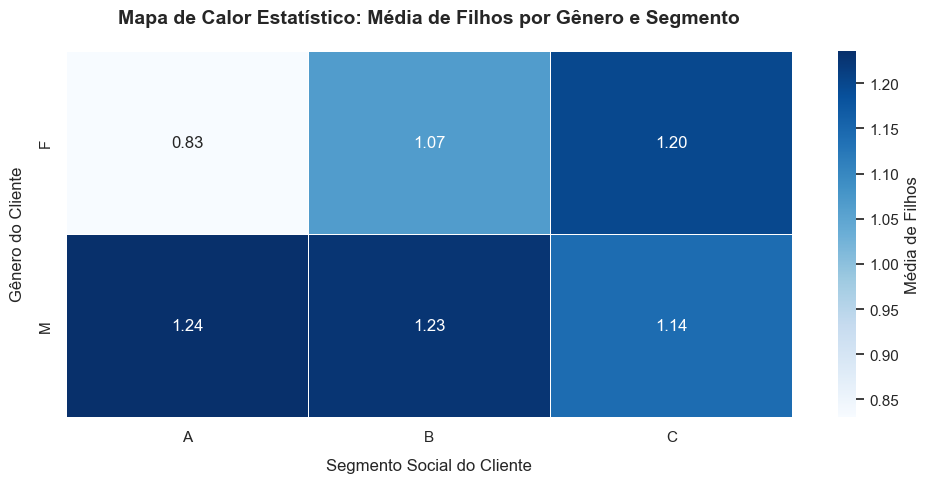

[OK] Mapa de calor estatístico exibido e salvou com sucesso!
     -> Arquivo gerado: 'heatmap_estatistico_sprint5.png'


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n" + "="*65)
print(" SPRINT 5 - MATRIZ ESTATÍSTICA: MÉDIA DE FILHOS POR GÊNERO E SEGMENTO")
print("="*65)

# 1. Construção da Tabela Pivô com a Média Estatística de Filhos (CL_FHL)
# Cruzamos Gênero nas linhas, Segmento nas colunas e calculamos a Média de filhos
matriz_media_filhos = df.pivot_table(
    values='CL_FHL', 
    index='CL_GENERO', 
    columns='CL_SEG', 
    aggfunc='mean'
)

print("MATRIZ DE MÉDIA DE FILHOS POR PERFIL DE CONSUMIDOR:")
print("-"*65)
# Exibe a tabela com 4 casas decimais para manter o padrão científico do projeto
print(matriz_media_filhos.to_string(formatters={col: lambda x: f"{x:.4f}" for col in matriz_media_filhos.columns}))
print("="*65)


# 2. Construção da Tabela Pivô com a Mediana de Filhos (para controle de outliers)
matriz_mediana_filhos = df.pivot_table(
    values='CL_FHL', 
    index='CL_GENERO', 
    columns='CL_SEG', 
    aggfunc='median'
)

print("\nMATRIZ DE MEDIANA DE FILHOS POR PERFIL DE CONSUMIDOR:")
print("-"*65)
print(matriz_mediana_filhos.to_string(formatters={col: lambda x: f"{x:.0f}" for col in matriz_mediana_filhos.columns}))
print("="*65)

# =================================================================
# GERANDO O GRÁFICO DE MAPA DE CALOR (HEATMAP) DA MÉDIA
# =================================================================
plt.figure(figsize=(10, 5))

# O Heatmap é o gráfico padrão de mercado para tabelas pivot_table
# annot=True coloca os números dentro dos quadrados, fmt=".2f" formata as casas decimais
ax = sns.heatmap(matriz_media_filhos, annot=True, fmt=".2f", cmap="Blues", 
                 linewidths=.5, cbar_kws={'label': 'Média de Filhos'})

# Configurações de títulos e eixos
plt.title("Mapa de Calor Estatístico: Média de Filhos por Gênero e Segmento", fontsize=14, pad=20, weight='bold')
plt.xlabel("Segmento Social do Cliente", fontsize=12, labelpad=10)
plt.ylabel("Gênero do Cliente", fontsize=12, labelpad=10)

plt.tight_layout()

# Salva a imagem do mapa de calor em alta resolução
nome_heatmap = 'heatmap_estatistico_sprint5.png'
plt.savefig(nome_heatmap, dpi=300, bbox_inches='tight')

# Exibe o gráfico na tela do VS Code
plt.show()

print(f"[OK] Mapa de calor estatístico exibido e salvou com sucesso!")
print(f"     -> Arquivo gerado: '{nome_heatmap}'")
print("="*65)


 SPRINT 5 - ANÁLISE TEMPORAL: CONSUMO DE ALIMENTOS NO FIM DE SEMANA
VOLUME DE COMPRAS DE ALIMENTOS AOS SÁBADOS E DOMINGOS POR GÊNERO:
-----------------------------------------------------------------
DIA_SEMANA CL_GENERO Volume de Compras
    Sábado         F            22.159
    Sábado         M            21.857
   Domingo         F            31.693
   Domingo         M            28.638


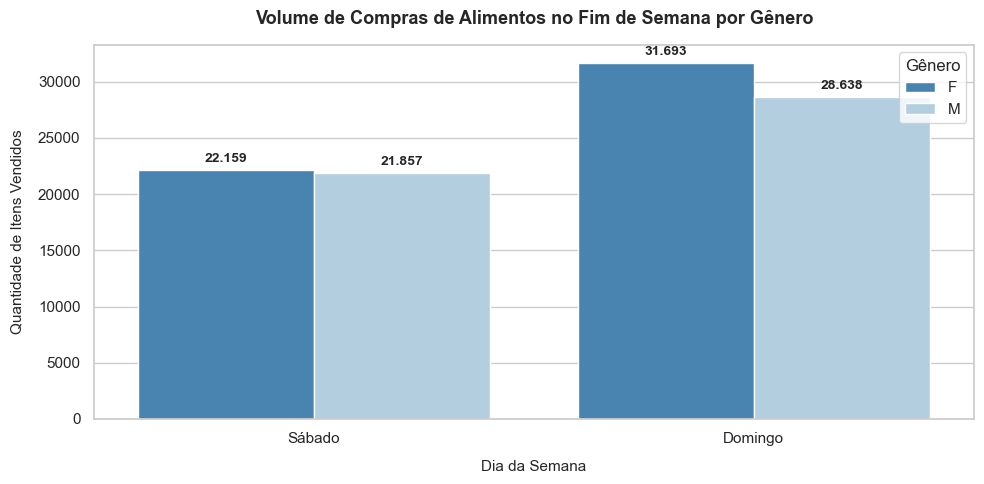

[OK] Análise concluída e gráfico salvo como 'analise_temporal_alimentos_sprint5.png'!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*65)
print(" SPRINT 5 - ANÁLISE TEMPORAL: CONSUMO DE ALIMENTOS NO FIM DE SEMANA")
print("="*65)

# === GARANTE QUE A BASE ESTÁ CARREGADA ===
try:
    df
except NameError:
    df = pd.read_csv('base_varejo_sprint3.csv', sep=',')

# === CORREÇÃO DO ERRO: Força a coluna DATA a virar formato de data real do Python ===
df['DATA'] = pd.to_datetime(df['DATA'], errors='coerce')

# 1. Agora o .dt.weekday vai funcionar perfeitamente!
df['DIA_SEMANA_NUM'] = df['DATA'].dt.weekday

# 2. Cria um mapeamento para salvar o nome do dia em português
dias_pt = {
    0: 'Segunda-feira', 1: 'Terça-feira', 2: 'Quarta-feira',
    3: 'Quinta-feira', 4: 'Sexta-feira', 5: 'Sábado', 6: 'Domingo'
}
df['DIA_SEMANA'] = df['DIA_SEMANA_NUM'].map(dias_pt)

# 3. Cria uma coluna para separar se é Fim de Semana (Sáb/Dom) ou Dia Útil
df['TIPO_DIA'] = df['DIA_SEMANA_NUM'].apply(lambda x: 'Fim de Semana' if x in [5, 6] else 'Dia Útil')

# =================================================================
# FILTRANDO ALIMENTOS NO FIM DE SEMANA
# =================================================================

# Filtramos a base para conter APENAS linhas de Fim de Semana E da categoria de Alimentos
filtro_alimentos_fds = (df['TIPO_DIA'] == 'Fim de Semana') & \
                       (df['PR_CAT'].astype(str).str.contains('ALIM', case=False, na=False))

df_alimentos_fds = df[filtro_alimentos_fds]

# 4. Agrupamos o resultado por Dia da Semana e Gênero do Cliente para contar o volume
analise_final = df_alimentos_fds.groupby(['DIA_SEMANA', 'CL_GENERO']).size().reset_index(name='Volume de Compras')

# Organiza para exibir Sábado primeiro e Domingo depois
analise_final['DIA_SEMANA'] = pd.Categorical(analise_final['DIA_SEMANA'], categories=['Sábado', 'Domingo'], ordered=True)
analise_final = analise_final.sort_values(['DIA_SEMANA', 'Volume de Compras'], ascending=[True, False])

print("VOLUME DE COMPRAS DE ALIMENTOS AOS SÁBADOS E DOMINGOS POR GÊNERO:")
print("-"*65)
print(analise_final.to_string(index=False, formatters={'Volume de Compras': lambda x: f"{x:,.0f}".replace(',', '.')}))
print("="*65)

# =================================================================
# PLOTANDO O GRÁFICO COMPLEMENTAR
# =================================================================
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=analise_final, x='DIA_SEMANA', y='Volume de Compras', hue='CL_GENERO', palette="Blues_r")

# Adiciona os números no topo das barras
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{int(altura):,}'.replace(',', '.'), 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=10, 
                    weight='bold')

plt.title("Volume de Compras de Alimentos no Fim de Semana por Gênero", fontsize=13, pad=15, weight='bold')
plt.xlabel("Dia da Semana", fontsize=11, labelpad=10)
plt.ylabel("Quantidade de Itens Vendidos", fontsize=11, labelpad=10)
plt.legend(title="Gênero", loc='upper right')

plt.tight_layout()

# Salva a imagem 
nome_grafico_tempo = 'analise_temporal_alimentos_sprint5.png'
plt.savefig(nome_grafico_tempo, dpi=300, bbox_inches='tight')
plt.show()

print(f"[OK] Análise concluída e gráfico salvo como '{nome_grafico_tempo}'!")
print("="*65)